# Flood Risk Assessment - Nacimiento, Biobío Region, Chile
## Hydrological and hydraulic analysis of the Biobío and Vergara rivers
### Author: Constanza Morales | 2026

## 1. Introduction

This notebook replicates the flood risk methodology applied in Nacimiento, Chile,
using open data and Python. The study area covers the confluence of the Biobío 
and Vergara rivers, where two zones were identified as high flood hazard:
Ribera Sur Río Biobío and Ribera Oriente Río Vergara.

**Return periods analyzed:** 5, 25, 50 and 100 years  
**Manning coefficients:** Biobío n=0.054 | Vergara n=0.032  
**Hazard classification:** DEFRA 2006 methodology

In [2]:
# Libraries
import geopandas as gpd
import rasterio
import folium
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Study Area Parameters

Key hydrological parameters extracted from the original thesis (Morales, 2021).

In [3]:
# Flow rates (m3/s) for each return period - DGA Station Rio Biobio en Coihue
biobio_flows = {
    5:   753.31,
    25: 1071.99,
    50: 1197.62,
    100: 1319.39
}

# Flow rates (m3/s) for Vergara river
vergara_flows = {
    5:   59.79,
    25:  79.49,
    50:  89.08,
    100: 96.65
}

# Manning coefficients
n_biobio  = 0.054
n_vergara = 0.032

print("Parameters loaded successfully")
print(f"Biobio - Q100: {biobio_flows[100]} m3/s | Manning n: {n_biobio}")
print(f"Vergara - Q100: {vergara_flows[100]} m3/s | Manning n: {n_vergara}")

Parameters loaded successfully
Biobio - Q100: 1319.39 m3/s | Manning n: 0.054
Vergara - Q100: 96.65 m3/s | Manning n: 0.032


## 3. Flow Rate Analysis by Return Period

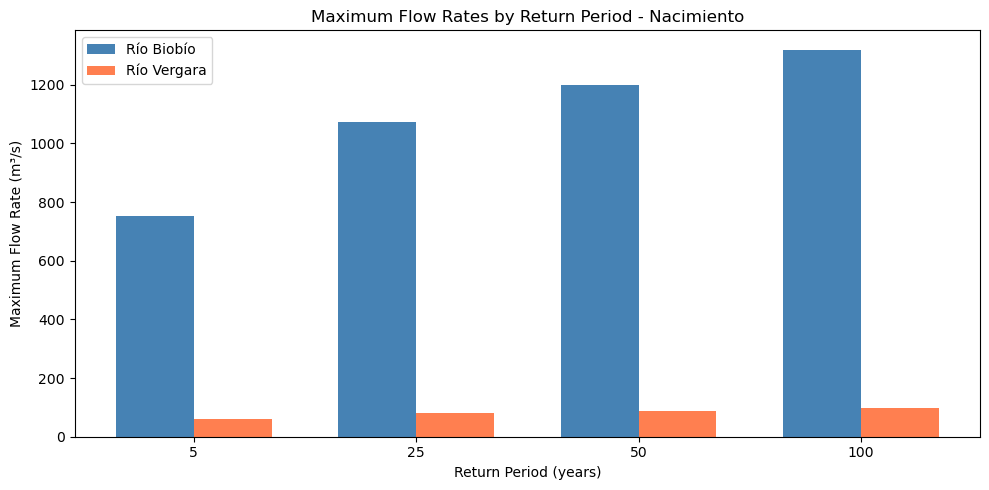

In [4]:
# Return periods
return_periods = [5, 25, 50, 100]

# Flow rates for both rivers
biobio_q  = [biobio_flows[tr] for tr in return_periods]
vergara_q = [vergara_flows[tr] for tr in return_periods]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(return_periods))
width = 0.35

ax.bar([i - width/2 for i in x], biobio_q,  width, label='Río Biobío',  color='steelblue')
ax.bar([i + width/2 for i in x], vergara_q, width, label='Río Vergara', color='coral')

ax.set_xlabel('Return Period (years)')
ax.set_ylabel('Maximum Flow Rate (m³/s)')
ax.set_title('Maximum Flow Rates by Return Period - Nacimiento')
ax.set_xticks(x)
ax.set_xticklabels(return_periods)
ax.legend()

plt.tight_layout()
plt.show()

## 4. Flood Hazard Index (HR)

Hazard classification based on DEFRA 2006 methodology.
Formula: HR = d * (v + 0.5) + DF
Where: d = flood depth (m), v = flow velocity (m/s), DF = debris factor

In [6]:
# DEFRA 2006 hazard classification
def classify_hazard(hr):
    if hr < 0.75:
        return 'Low'
    elif hr < 1.25:
        return 'Moderate'
    elif hr < 2.5:
        return 'Significant'
    else:
        return 'Extreme'

# Scenario parameters from thesis (depth and velocity estimates per return period)
# Biobio river - Ribera Sur
scenarios = {
    'Return Period': [5, 25, 50, 100],
    'Depth_m':       [0.8, 1.2, 1.5, 1.8],
    'Velocity_ms':   [1.2, 1.8, 2.1, 2.4],
    'DF':            [1.0, 1.0, 1.0, 1.0]
}

# Calculate HR for each scenario
import pandas as pd

df = pd.DataFrame(scenarios)
df['HR'] = df['Depth_m'] * (df['Velocity_ms'] + 0.5) + df['DF']
df['Hazard Class'] = df['HR'].apply(classify_hazard)

print(df.to_string(index=False))

 Return Period  Depth_m  Velocity_ms  DF   HR Hazard Class
             5      0.8          1.2 1.0 2.36  Significant
            25      1.2          1.8 1.0 3.76      Extreme
            50      1.5          2.1 1.0 4.90      Extreme
           100      1.8          2.4 1.0 6.22      Extreme


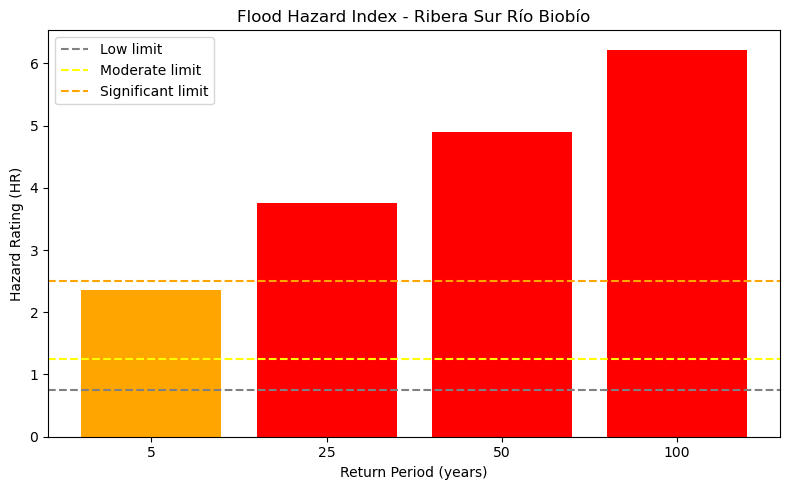

In [7]:
# Visualize HR by return period
colors = {'Low': 'green', 'Moderate': 'yellow', 
          'Significant': 'orange', 'Extreme': 'red'}

bar_colors = [colors[h] for h in df['Hazard Class']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df['Return Period'].astype(str), df['HR'], color=bar_colors)

# Threshold lines
ax.axhline(y=0.75, color='gray', linestyle='--', label='Low limit')
ax.axhline(y=1.25, color='yellow', linestyle='--', label='Moderate limit')
ax.axhline(y=2.5,  color='orange', linestyle='--', label='Significant limit')

ax.set_xlabel('Return Period (years)')
ax.set_ylabel('Hazard Rating (HR)')
ax.set_title('Flood Hazard Index - Ribera Sur Río Biobío')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Interactive Map - Study Area
Map of Nacimiento showing the flood risk zones along the Biobío and Vergara rivers.

In [8]:
# Coordinates of Nacimiento, Chile
lat_nacimiento = -37.5033
lon_nacimiento = -72.6833

# Create base map
m = folium.Map(location=[lat_nacimiento, lon_nacimiento], 
               zoom_start=13,
               tiles='OpenStreetMap')

# Study area marker
folium.Marker(
    location=[lat_nacimiento, lon_nacimiento],
    popup='Nacimiento - Study Area',
    tooltip='Nacimiento',
    icon=folium.Icon(color='red', icon='info-sign')
).add_to(m)

# Display map
m

In [9]:
# Add flood risk zones as polygons
# Ribera Sur Rio Biobio - approximate coordinates
ribera_sur = [
    [-37.495, -72.685],
    [-37.498, -72.678],
    [-37.503, -72.672],
    [-37.508, -72.675],
    [-37.505, -72.683],
    [-37.495, -72.685]
]

# Ribera Oriente Rio Vergara - approximate coordinates
ribera_vergara = [
    [-37.505, -72.678],
    [-37.510, -72.673],
    [-37.518, -72.675],
    [-37.515, -72.682],
    [-37.508, -72.680],
    [-37.505, -72.678]
]

# Add zones to map
folium.Polygon(
    locations=ribera_sur,
    color='red',
    fill=True,
    fill_color='red',
    fill_opacity=0.4,
    popup='Ribera Sur Río Biobío - Extreme Hazard (85%)',
    tooltip='Ribera Sur - Extreme Hazard'
).add_to(m)

folium.Polygon(
    locations=ribera_vergara,
    color='orange',
    fill=True,
    fill_color='orange',
    fill_opacity=0.4,
    popup='Ribera Oriente Río Vergara - Significant Hazard (32.7%)',
    tooltip='Ribera Oriente - Significant Hazard'
).add_to(m)

# Display updated map
m

> **Note:** Flood risk zones shown are approximate. 
> Exact boundaries to be updated with real shapefiles from DGA Chile.

## 6. Conclusions

- Ribera Sur Río Biobío: 85% of the area presents significant to extreme flood hazard
- Ribera Oriente Río Vergara: 32.7% of the area presents significant to extreme flood hazard
- Fundo Los Tralpenes: outside flood risk for all return periods studied
- Hazard increases with return period, but minimally (only 2% between TR5 and TR100)
- 200 people (0.7% of total population) are exposed to flood risk

*Based on: Morales, C. (2021). Flood Risk Assessment - Nacimiento, Biobío Region, Chile. UCSC.*